In [1]:
import pandas as pd
import numpy as np
import pickle as pkl
import toolkit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [2]:
with open("data/preprocessed_trainig.pkl", "rb") as file:
    train = pkl.load(file)

In [3]:
train.shape

(10628, 88)

In [4]:
train.head()

,.,.>,2002,the,from,with,.Received:,+0100,a,for,...,.Reply-To:,our,<a,.<table,We,/>,.<td,Helvetica,Status,domain
0,20,14,9,9,7,7,7,5,5,4,...,0,0,0,0,0,0,0,0,0,linux.ie
1,6,0,5,0,3,3,3,3,0,1,...,0,0,0,0,0,0,0,0,0,jmason.org
2,21,9,11,2,8,8,8,4,2,3,...,0,0,0,0,0,0,0,0,0,lists.sourceforge.net
3,35,0,6,12,5,6,4,2,5,4,...,1,3,1,0,0,0,12,10,2,unimportant
4,16,0,8,1,6,5,6,3,1,4,...,0,0,0,0,0,0,0,0,0,xent.com


In [5]:
ohe = OneHotEncoder(handle_unknown="ignore")

In [6]:
X_train, y_train = train.drop("Status", axis=1), train["Status"] 

In [7]:
X_train.head()

,.,.>,2002,the,from,with,.Received:,+0100,a,for,...,had,.Reply-To:,our,<a,.<table,We,/>,.<td,Helvetica,domain
0,20,14,9,9,7,7,7,5,5,4,...,0,0,0,0,0,0,0,0,0,linux.ie
1,6,0,5,0,3,3,3,3,0,1,...,0,0,0,0,0,0,0,0,0,jmason.org
2,21,9,11,2,8,8,8,4,2,3,...,0,0,0,0,0,0,0,0,0,lists.sourceforge.net
3,35,0,6,12,5,6,4,2,5,4,...,0,1,3,1,0,0,0,12,10,unimportant
4,16,0,8,1,6,5,6,3,1,4,...,0,0,0,0,0,0,0,0,0,xent.com


In [8]:
del train

In [9]:
ct = ColumnTransformer(
    [
        ("ohe", OneHotEncoder(handle_unknown="ignore"), ["domain"]),
        ("scalling", StandardScaler(), X_train.columns[:-1])
    ]
)

In [10]:
ct.fit(X_train)

ColumnTransformer(transformers=[('ohe', OneHotEncoder(handle_unknown='ignore'),
                                 ['domain']),
                                ('scalling', StandardScaler(),
                                 Index(['.', '.>', '2002', 'the', 'from', 'with', '.Received:', '+0100', 'a',
       'for', 'id', 'by', 'ESMTP', 'Linux', 'you', 'to', '[127.0.0.1]', 'I',
       'it', '-0000', 'Microsoft', 'my', 'that', 'have', '[127.0.0.1])',
       'localhost', 'on', 'SMTP', 'be', '(Postfix)', '(...
       'of', '.X-Beenthere:', '.X-Mailman-Version:', 'bulk', '.List-Id:',
       '.Precedence:', '.Sender:', 'and', 'your', 'can', 'or', '--',
       '<jm@localhost>;', 'jalapeno', 'jm@localhost', '(jalapeno', 'this',
       'but', '#1', '-0700', 'than', 'was', 'email', 'fork-admin@xent.com',
       'xent.com', '(PDT)', 'his', 'e-mail', 'had', '.Reply-To:', 'our', '<a',
       '.<table', 'We', '/>', '.<td', 'Helvetica'],
      dtype='object'))])

In [11]:
X_train = ct.transform(X_train)

In [12]:
with open("./pickled_objects/columnTransformer.pkl", "wb") as file:
    pkl.dump(ct, file)

In [13]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, stratify=y_train, test_size=0.1)

In [14]:
X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((9565, 120), (9565,), (1063, 120), (1063,))

In [15]:
y_train = (y_train == 2)
y_valid = (y_valid == 2)

# Modelling
## Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

In [35]:
gs = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid={
        "penalty" : ["l2", None],
        "solver" : ["lbfgs", "newton-cg", "newton-cholesky", "sag", "saga"],
        "max_iter" : [20, 50, 100, 200]
    },
    cv=5,
    n_jobs=-1
)

In [36]:
gs.fit(X_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'max_iter': [20, 50, 100, 200],
                         'penalty': ['l2', None],
                         'solver': ['lbfgs', 'newton-cg', 'newton-cholesky',
                                    'sag', 'saga']})

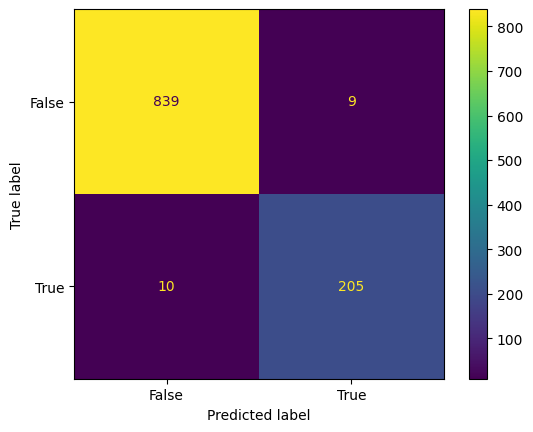

In [37]:
lr = gs.best_estimator_
y_pred_valid = lr.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)

In [38]:
print(classification_report(y_pred=y_pred_valid, y_true=y_valid))

              precision    recall  f1-score   support

       False       0.99      0.99      0.99       848
        True       0.96      0.95      0.96       215

    accuracy                           0.98      1063
   macro avg       0.97      0.97      0.97      1063
weighted avg       0.98      0.98      0.98      1063



In [41]:
lr.solver, lr.max_iter

('lbfgs', 100)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


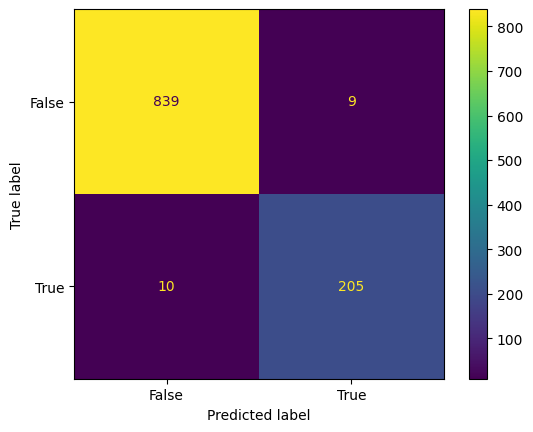

In [42]:
gs = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid={
        "penalty" : ["l2", None],
        "solver" : ["lbfgs"],
        "max_iter" : np.arange(50, 151, 10)
    },
    cv=5,
    n_jobs=-1
)
gs.fit(X_train, y_train)
lr = gs.best_estimator_
y_pred_valid = lr.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)

In [44]:
print(classification_report(y_pred=y_pred_valid, y_true=y_valid))

              precision    recall  f1-score   support

       False       0.99      0.99      0.99       848
        True       0.96      0.95      0.96       215

    accuracy                           0.98      1063
   macro avg       0.97      0.97      0.97      1063
weighted avg       0.98      0.98      0.98      1063



In [45]:
lr = gs.best_estimator_

In [46]:
lr.max_iter, lr.solver, lr.penalty

(np.int64(100), 'lbfgs', None)

In [47]:
with open("models/LogisticRegressor.pkl", "wb") as file:
    model = LogisticRegression(random_state=42, penalty=None, solver='lbfgs', max_iter=100)
    model.fit(X_train, y_train)
    pkl.dump(model, file)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [48]:
gs = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid={
        "penalty" : ["l2", "l1"],
        "solver" : ["liblinear", "saga"],
        "max_iter" : [20, 30, 40, 50, 100, 200]
    },
    cv=5,
    n_jobs=-1
)

In [49]:
gs.fit(X_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'max_iter': [20, 30, 40, 50, 100, 200],
                         'penalty': ['l2', 'l1'],
                         'solver': ['liblinear', 'saga']})

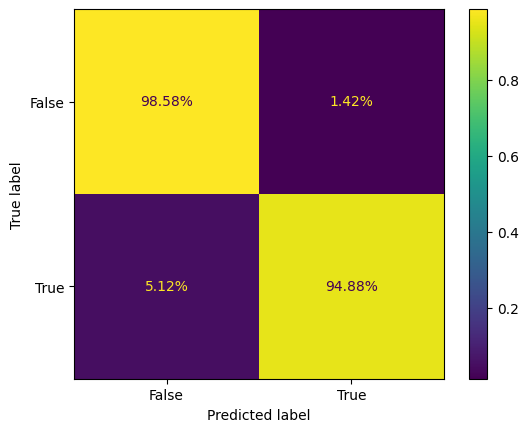

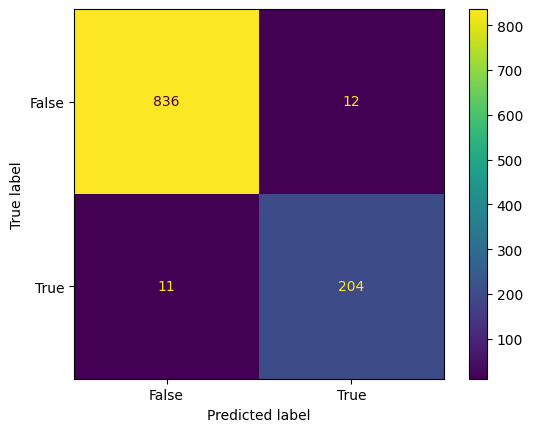

In [50]:
lr2 = gs.best_estimator_
y_pred_valid2 = lr2.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid2, normalize="true", values_format=".2%")
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid2)

In [51]:
print(classification_report(y_pred=y_pred_valid2, y_true=y_valid))

              precision    recall  f1-score   support

       False       0.99      0.99      0.99       848
        True       0.94      0.95      0.95       215

    accuracy                           0.98      1063
   macro avg       0.97      0.97      0.97      1063
weighted avg       0.98      0.98      0.98      1063



In [52]:
y_pred_valid = lr.predict(X_valid)

In [53]:
np.mean(y_pred_valid == y_valid), np.mean(y_pred_valid2 == y_valid)

(np.float64(0.9821260583254939), np.float64(0.9783631232361242))

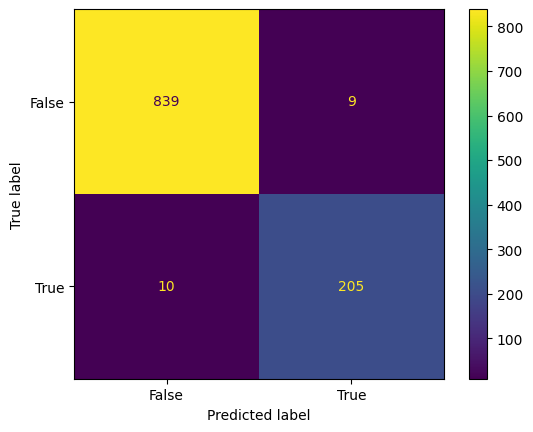

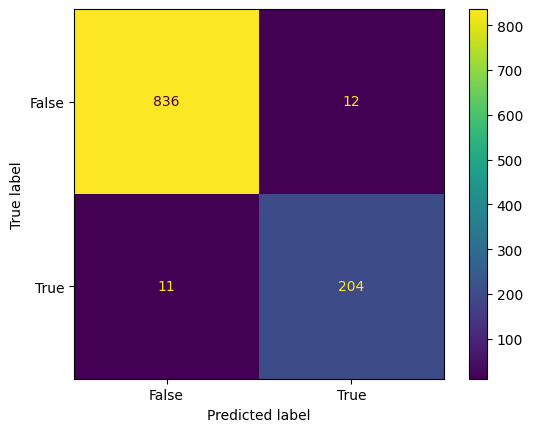

In [54]:
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid2)

In [55]:
lr, lr2

(LogisticRegression(max_iter=np.int64(100), penalty=None, random_state=42),
 LogisticRegression(max_iter=20, penalty='l1', random_state=42,
                    solver='liblinear'))

In [56]:
with open("models/LogisticRegressor2.pkl", "wb") as file:
    model = LogisticRegression(random_state=42, penalty="l1", solver='liblinear', max_iter=20)
    model.fit(X_train, y_train)
    pkl.dump(model, file)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [57]:
lr.penalty

In [58]:
gs = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid={
        "penalty" : ["l1"],
        "solver" : ['liblinear'],
        "max_iter" : np.arange(10, 31, 1)
    },
    cv=3,
    n_jobs=-1
)
gs.fit(X_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


GridSearchCV(cv=3, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'max_iter': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30]),
                         'penalty': ['l1'], 'solver': ['liblinear']})

In [59]:
gs = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid={
        "penalty" : ["l2"],
        "solver" : ["newton-cholesky"],
        "max_iter" : np.arange(1, 11)
    },
    cv=3,
    n_jobs=-1
)
gs.fit(X_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_glm\_newton_solver.py:431: ConvergenceWarning: Newton solver did not converge after 6 iterations.
  warnings.warn(


GridSearchCV(cv=3, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'max_iter': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'penalty': ['l2'], 'solver': ['newton-cholesky']})

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_glm\_newton_solver.py:431: ConvergenceWarning: Newton solver did not converge after 6 iterations.
  warnings.warn(


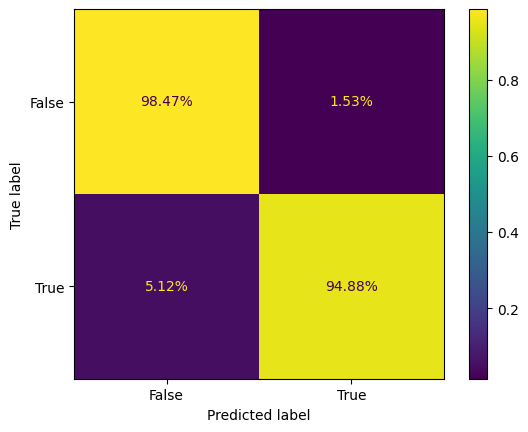

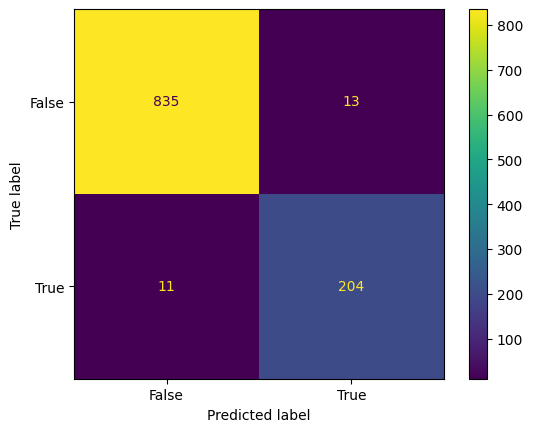

In [60]:
lr = gs.best_estimator_
lr.fit(X_train, y_train)
y_pred_valid2 = lr.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid2, normalize="true", values_format=".2%")
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid2)

In [35]:
model = LogisticRegression(max_iter = 50, penalty=None, random_state=42,solver="newton-cg")
model.fit(X_train, y_train)
with open("models/LogisticRegressor.pkl", "wb") as file:
    pkl.dump(model, file)

model = LogisticRegression(max_iter=30, penalty="l1", random_state=42, solver="liblinear")
model.fit(X_train, y_train)
with open("models/LogisticRegressor2.pkl", "wb") as file:
    pkl.dump(model, file)

### Results
As we can see, the difference is not tha much but the 2nd classfier has smaller recall which may be a disadvantage in this case.

## K Nearest Neighbours

In [64]:
from sklearn.neighbors import KNeighborsClassifier

In [65]:
gs = GridSearchCV(
    estimator=KNeighborsClassifier(n_jobs=-1),
    param_grid={
        "n_neighbors" : np.arange(1, 11, 1),
        "weights" : ["uniform", "distance"],
        "metric" : ["l1", "l2", "cosine"]
    },
    n_jobs=-1,
    cv=3
)

In [66]:
X_train.shape

(9565, 120)

In [67]:
gs.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=KNeighborsClassifier(n_jobs=-1), n_jobs=-1,
             param_grid={'metric': ['l1', 'l2', 'cosine'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'weights': ['uniform', 'distance']})

In [68]:
knn = gs.best_estimator_

In [69]:
knn.weights

'uniform'

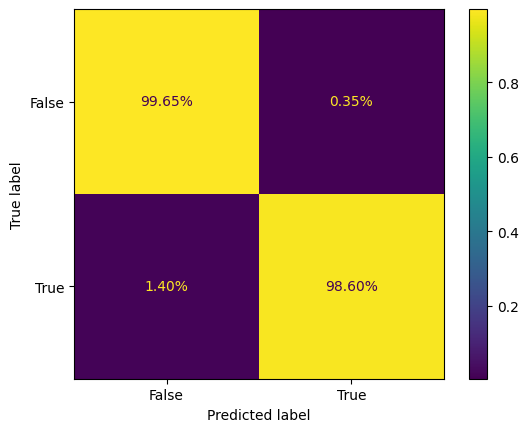

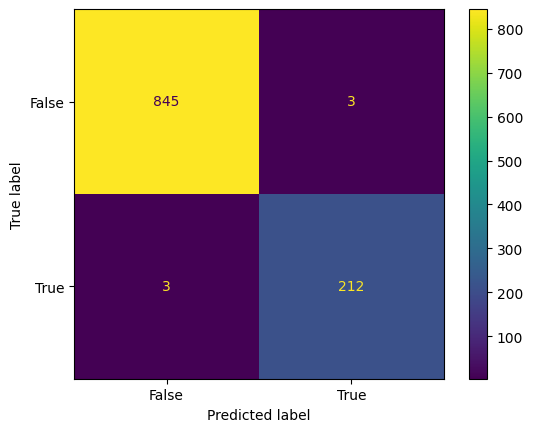

In [70]:
y_pred_valid = knn.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid, normalize="true", values_format=".2%")
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)

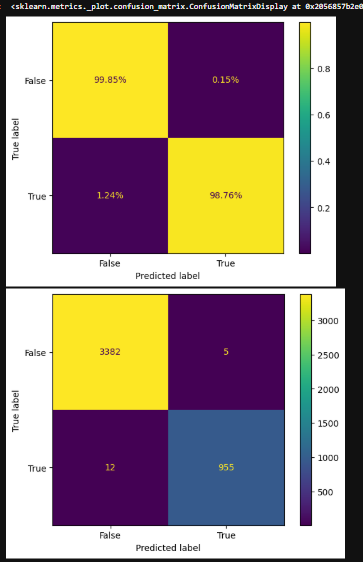

In [71]:
print(classification_report(y_pred=y_pred_valid, y_true=y_valid))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       848
        True       0.99      0.99      0.99       215

    accuracy                           0.99      1063
   macro avg       0.99      0.99      0.99      1063
weighted avg       0.99      0.99      0.99      1063



In [72]:
np.mean(y_pred_valid==y_valid)

np.float64(0.9943555973659455)

In [73]:
with open("models/KNNClassifier.pkl", "wb") as file:
    model = KNeighborsClassifier(n_neighbors=1, weights="uniform", metric="l1")
    model.fit(X_train, y_train)
    pkl.dump(model, file)

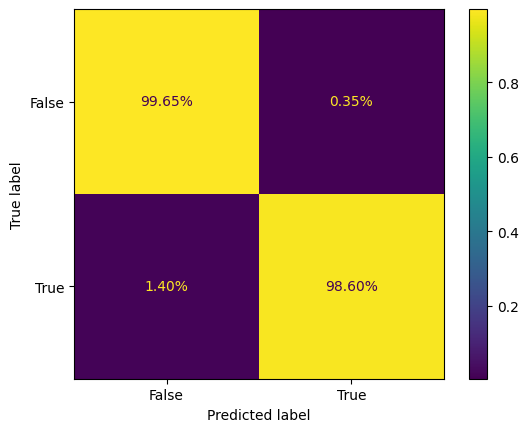

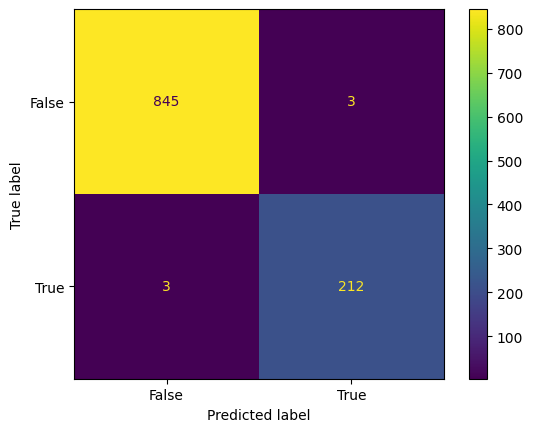

In [74]:
y_pred_valid = model.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid, normalize="true", values_format=".2%")
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)

### Results
Great succes, I guess. Probalty it's an effect of cruciality of domains, from where the e-mails are sent.

## Decision Trees

In [75]:
from sklearn.tree import DecisionTreeClassifier

In [80]:
gs = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid={
        "criterion" : ["gini", "entropy", "log_loss"],
        "max_depth" : [10, 20, 30, 50, 70, 100],
        "min_samples_split" : np.arange(2, 6, 1),
    },
    cv=3,
    n_jobs=-1
)

In [81]:
gs.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [10, 20, 30, 50, 70, 100],
                         'min_samples_split': array([2, 3, 4, 5])})

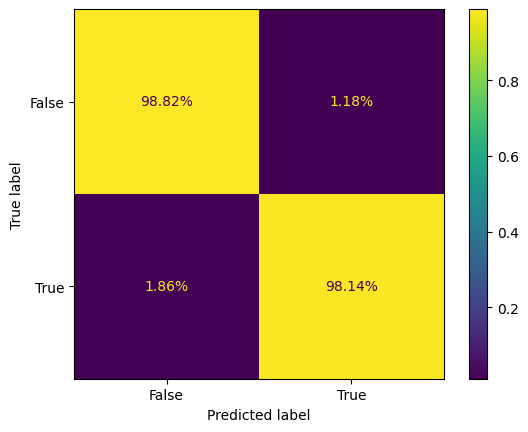

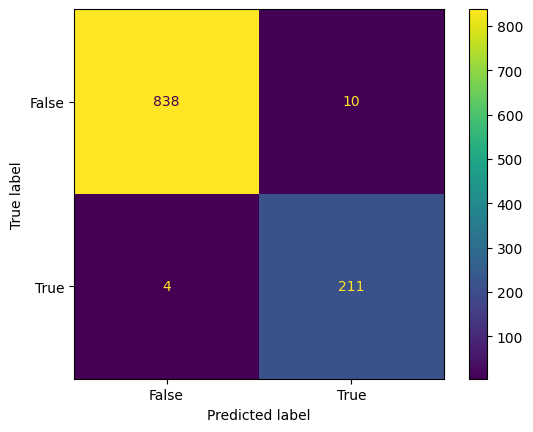

In [82]:
dc = gs.best_estimator_
y_pred_valid = gs.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid, normalize="true", values_format=".2%")
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)

In [83]:
gss = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid={
        "criterion" : ["gini", "entropy", "log_loss"],
        "max_depth" : np.arange(2, 30, 1),
        "min_samples_split" : np.arange(2, 6, 1)
    },
    cv=3,
    n_jobs=-1
)

In [84]:
gss.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]),
                         'min_samples_split': array([2, 3, 4, 5])})

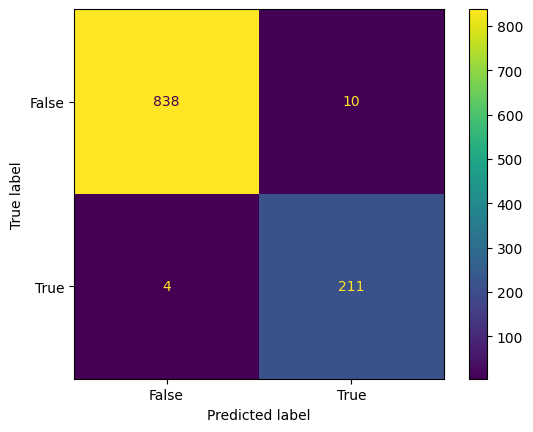

In [85]:
dc = gss.best_estimator_
y_pred_valid = gs.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)

In [86]:
with open("models/DecisionTree.pkl", "wb") as file:
    pkl.dump(dc, file)

In [87]:
gss = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid={
        "criterion" : ["gini"],
        "max_depth" : np.arange(120, 141, 1),
        "min_samples_split" : np.arange(2, 6, 1)
    },
    cv=3,
    n_jobs=-1
)

In [88]:
gss.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini'],
                         'max_depth': array([120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132,
       133, 134, 135, 136, 137, 138, 139, 140]),
                         'min_samples_split': array([2, 3, 4, 5])})

In [89]:
dc = gss.best_estimator_

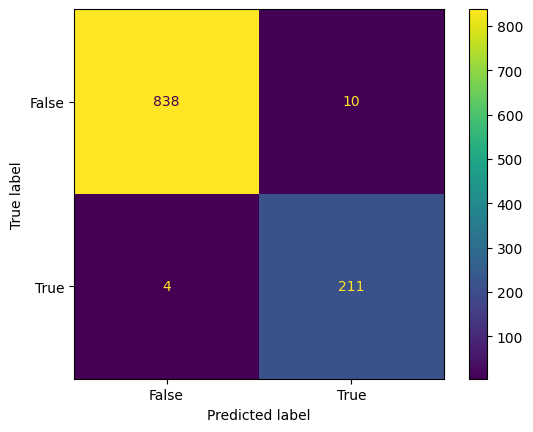

In [90]:
dc = gs.best_estimator_
y_pred_valid = dc.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)

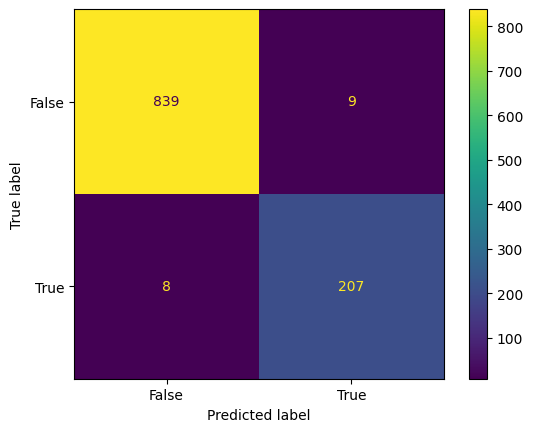

In [92]:
gss = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid={
        "criterion" : ["gini"],
        "max_depth" : np.arange(140, 161, 1),
        "min_samples_split" : np.arange(2, 6, 1)
    },
    cv=3,
    n_jobs=-1
)
gss.fit(X_train, y_train)
dc = gss.best_estimator_
y_pred_valid = dc.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)

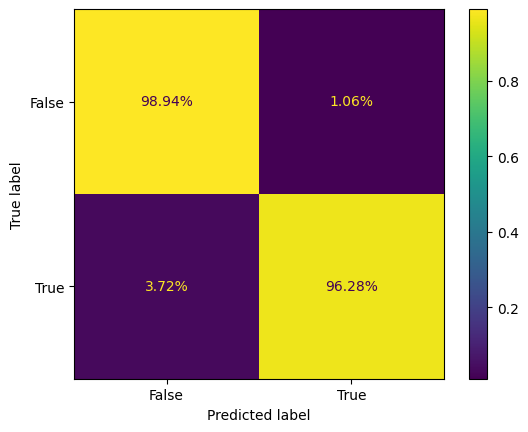

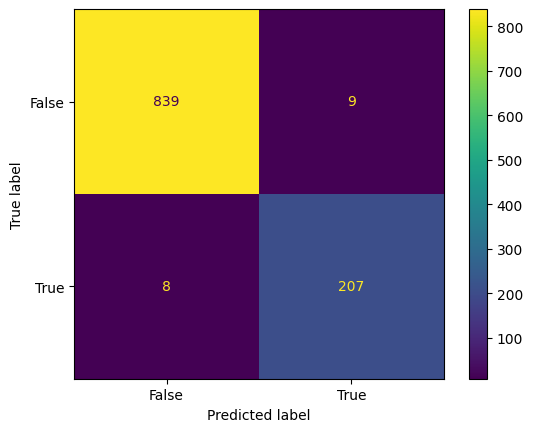

In [93]:
dc = gss.best_estimator_
y_pred_valid = dc.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid, normalize="true", values_format=".2%")
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)

In [94]:
print(classification_report(y_pred=y_pred_valid, y_true=y_valid))

              precision    recall  f1-score   support

       False       0.99      0.99      0.99       848
        True       0.96      0.96      0.96       215

    accuracy                           0.98      1063
   macro avg       0.97      0.98      0.98      1063
weighted avg       0.98      0.98      0.98      1063



In [95]:
np.mean(y_pred_valid == y_valid)

np.float64(0.9840075258701787)

In [96]:
gss = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid={
        "criterion" : ["gini"],
        "max_depth" : np.arange(20, 41, 1),
        "min_samples_split" : np.arange(2, 4, 1)
    },
    cv=3,
    n_jobs=-1
)
gss.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini'],
                         'max_depth': array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38, 39, 40]),
                         'min_samples_split': array([2, 3])})

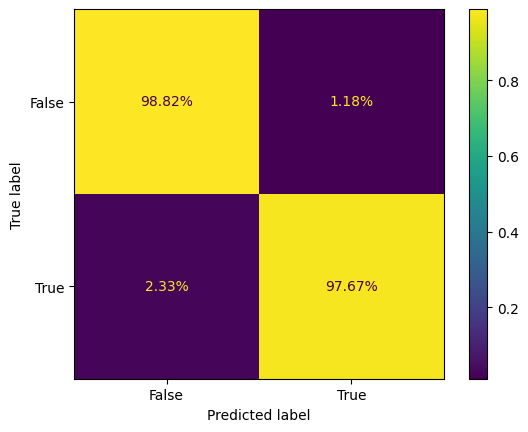

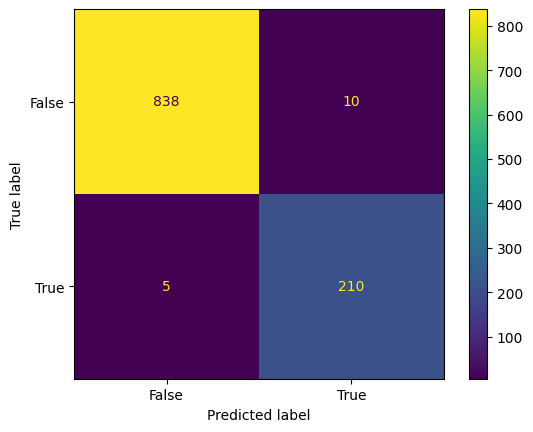

In [97]:
dc = gss.best_estimator_
y_pred_valid = dc.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid, normalize="true", values_format=".2%")
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)

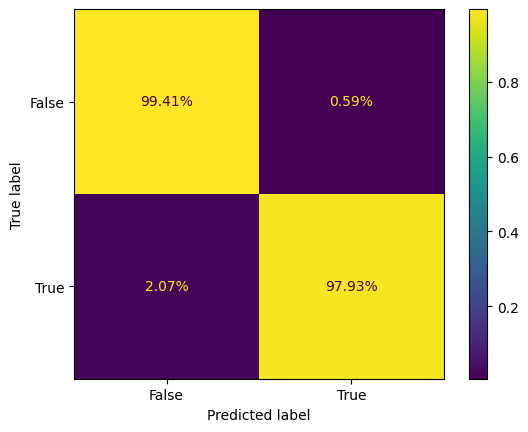

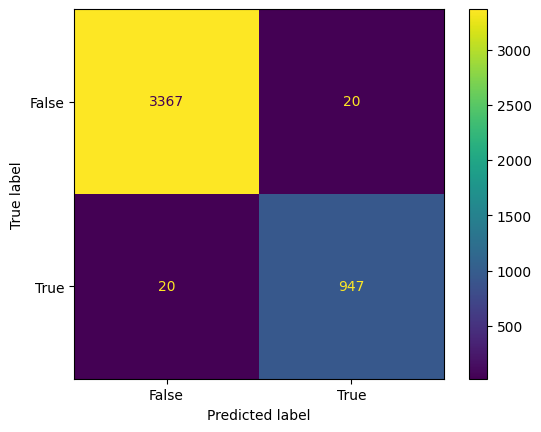

In [69]:
dc = model
y_pred_valid = dc.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid, normalize="true", values_format=".2%")
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)

### Results
Again, we achieved high scores. Interesingly, with max_depth = 24 the best min_samples_split was 2, which is similar to KNearestNeighboursClassifier with the best n_neighbour=1 param.

## Random Forest

In [98]:
from sklearn.ensemble import RandomForestClassifier

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       848
        True       0.98      0.99      0.98       215

    accuracy                           0.99      1063
   macro avg       0.99      0.99      0.99      1063
weighted avg       0.99      0.99      0.99      1063



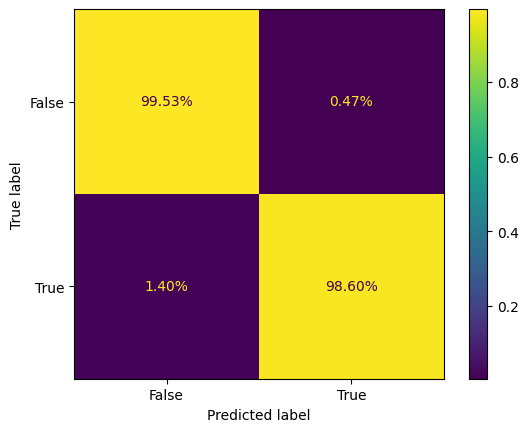

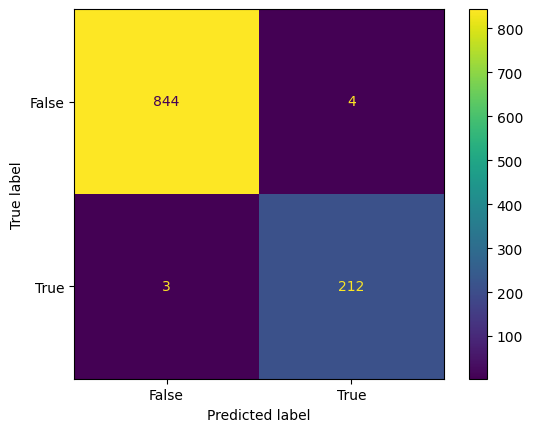

In [99]:
rf = RandomForestClassifier(random_state=42, min_samples_leaf=1, min_samples_split=3, max_depth=94, n_estimators=200)
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid, normalize="true", values_format=".2%")
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       848
        True       0.98      0.99      0.98       215

    accuracy                           0.99      1063
   macro avg       0.99      0.99      0.99      1063
weighted avg       0.99      0.99      0.99      1063



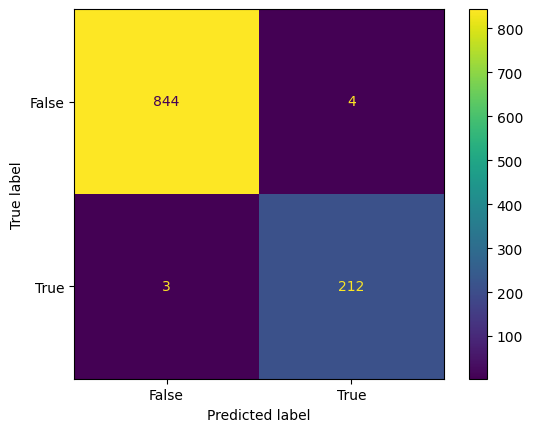

In [100]:
rf = RandomForestClassifier(random_state=42, min_samples_leaf=1, min_samples_split=3, max_depth=94, n_estimators=500)
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       848
        True       0.98      0.99      0.99       215

    accuracy                           0.99      1063
   macro avg       0.99      0.99      0.99      1063
weighted avg       0.99      0.99      0.99      1063



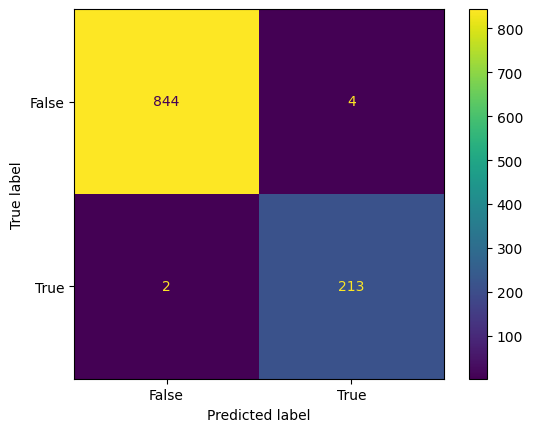

In [101]:
rf = RandomForestClassifier(random_state=42, min_samples_leaf=1, min_samples_split=3, max_depth=94, n_estimators=30)
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

              precision    recall  f1-score   support

       False       1.00      0.99      1.00       848
        True       0.98      0.99      0.98       215

    accuracy                           0.99      1063
   macro avg       0.99      0.99      0.99      1063
weighted avg       0.99      0.99      0.99      1063



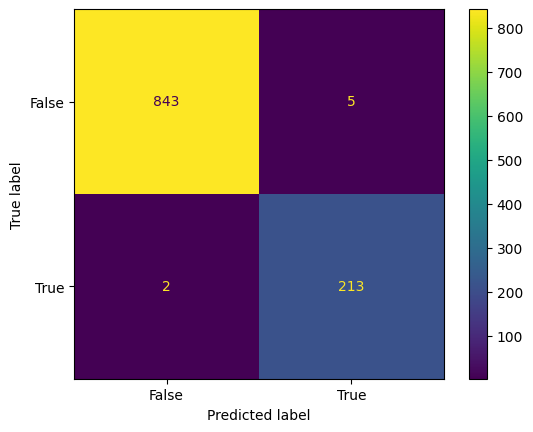

In [102]:
rf = RandomForestClassifier(random_state=42, min_samples_leaf=1, min_samples_split=3, max_depth=94, n_estimators=20)
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       848
        True       0.99      0.99      0.99       215

    accuracy                           1.00      1063
   macro avg       0.99      0.99      0.99      1063
weighted avg       1.00      1.00      1.00      1063



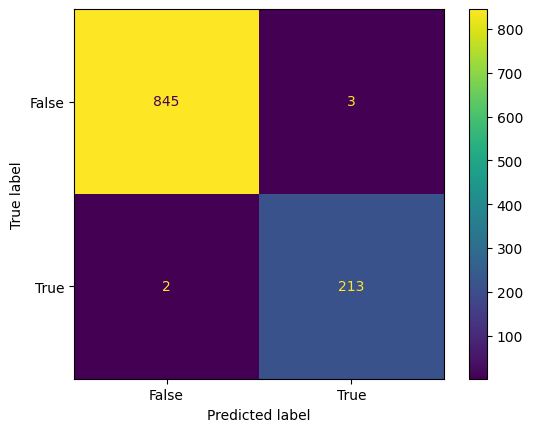

In [103]:
rf = RandomForestClassifier(random_state=42, min_samples_leaf=1, min_samples_split=3, max_depth=None, n_estimators=50)
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       848
        True       0.99      0.99      0.99       215

    accuracy                           1.00      1063
   macro avg       0.99      0.99      0.99      1063
weighted avg       1.00      1.00      1.00      1063



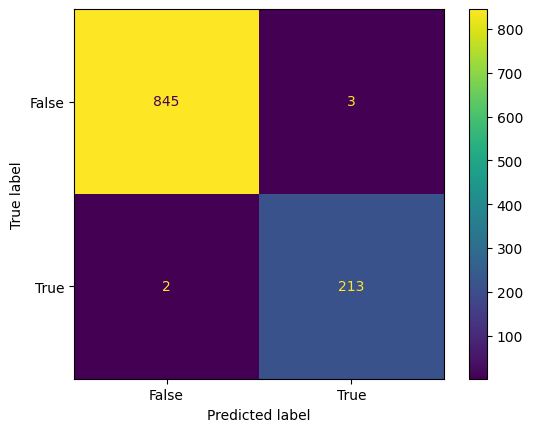

In [105]:
rf = RandomForestClassifier(random_state=42, min_samples_leaf=1, min_samples_split=3, max_depth=94, n_estimators=40)
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

In [106]:
with open("models/RandomForest.pkl", "wb") as file:
    pkl.dump(rf, file)

### The Second Attempt

In [107]:
gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1, min_samples_split=3),
    param_grid={
        "n_estimators" : np.arange(20, 61, 1),
        "criterion" : ["gini"],
        "max_depth" : [None] + list(np.arange(80, 101, 4))
    },
    cv=3,
    n_jobs=-1,
    verbose=1,
)

In [108]:
gs.fit(X_train, y_train)

Fitting 3 folds for each of 287 candidates, totalling 861 fits


GridSearchCV(cv=3,
             estimator=RandomForestClassifier(min_samples_split=3, n_jobs=-1,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini'],
                         'max_depth': [None, np.int64(80), np.int64(84),
                                       np.int64(88), np.int64(92), np.int64(96),
                                       np.int64(100)],
                         'n_estimators': array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
       54, 55, 56, 57, 58, 59, 60])},
             verbose=1)

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       848
        True       0.98      0.99      0.99       215

    accuracy                           0.99      1063
   macro avg       0.99      0.99      0.99      1063
weighted avg       0.99      0.99      0.99      1063



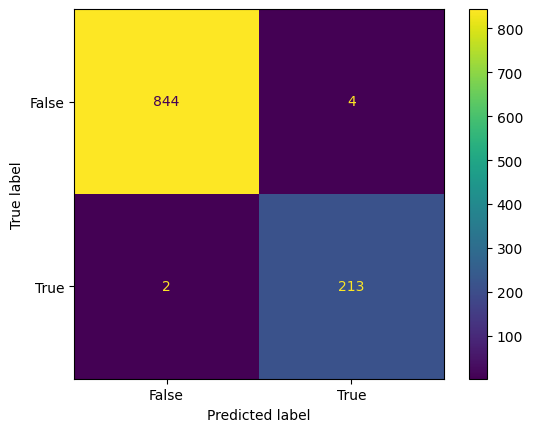

In [109]:
rf = gs.best_estimator_
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

In [110]:
rf.max_depth

In [111]:
gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid={
        "n_estimators" : np.arange(20, 41, 1),
        "criterion" : ["gini"],
        "max_depth" : [None],
        "min_samples_split" : np.arange(2, 6, 1)
    },
    cv=3,
    n_jobs=-1,
    verbose=1,
)

In [112]:
gs.fit(X_train, y_train)

Fitting 3 folds for each of 84 candidates, totalling 252 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini'], 'max_depth': [None],
                         'min_samples_split': array([2, 3, 4, 5]),
                         'n_estimators': array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38, 39, 40])},
             verbose=1)

In [113]:
gs.best_estimator_

RandomForestClassifier(min_samples_split=np.int64(2), n_estimators=np.int64(39),
                       n_jobs=-1, random_state=42)

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       848
        True       0.98      0.98      0.98       215

    accuracy                           0.99      1063
   macro avg       0.99      0.99      0.99      1063
weighted avg       0.99      0.99      0.99      1063



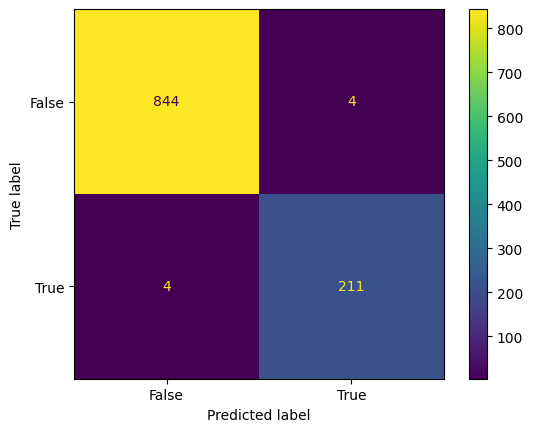

In [114]:
rf = gs.best_estimator_
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       848
        True       0.98      0.98      0.98       215

    accuracy                           0.99      1063
   macro avg       0.99      0.99      0.99      1063
weighted avg       0.99      0.99      0.99      1063



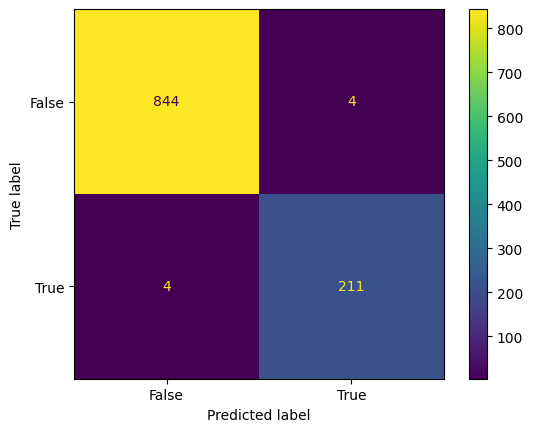

In [115]:
rf = RandomForestClassifier(min_samples_split=2, n_estimators=39, max_depth=None, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

In [116]:
np.mean(y_valid==y_pred_valid)

np.float64(0.9924741298212606)

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       848
        True       0.98      0.99      0.99       215

    accuracy                           0.99      1063
   macro avg       0.99      0.99      0.99      1063
weighted avg       0.99      0.99      0.99      1063



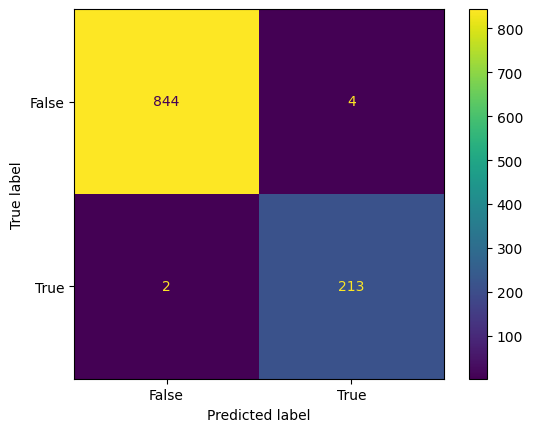

In [117]:
rf2 = RandomForestClassifier(random_state=42, min_samples_leaf=1, min_samples_split=3, max_depth=None, n_estimators=30)
rf2.fit(X_train, y_train)
y_pred_valid = rf2.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

In [118]:
gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid={
        "n_estimators" : np.arange(30, 50, 1),
        "criterion" : ["gini"],
        "max_depth" : [None] + list(np.arange(90, 101, 1)),
        "min_samples_split" : np.arange(2, 4, 1)
    },
    cv=5,
    n_jobs=-1,
    verbose=1,
)

In [119]:
gs.fit(X_train, y_train)

Fitting 5 folds for each of 480 candidates, totalling 2400 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini'],
                         'max_depth': [None, np.int64(90), np.int64(91),
                                       np.int64(92), np.int64(93), np.int64(94),
                                       np.int64(95), np.int64(96), np.int64(97),
                                       np.int64(98), np.int64(99),
                                       np.int64(100)],
                         'min_samples_split': array([2, 3]),
                         'n_estimators': array([30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46,
       47, 48, 49])},
             verbose=1)

In [120]:
gs.best_estimator_.max_depth

              precision    recall  f1-score   support

       False       0.99      1.00      0.99       848
        True       0.98      0.98      0.98       215

    accuracy                           0.99      1063
   macro avg       0.99      0.99      0.99      1063
weighted avg       0.99      0.99      0.99      1063



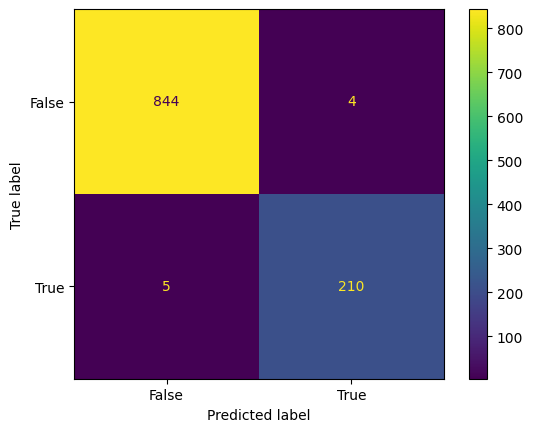

In [121]:
rf = gs.best_estimator_
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

In [122]:
rf.max_depth

In [123]:
with open("models/RandomForest2.pkl", "wb") as file:
    pkl.dump(rf, file)

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       848
        True       0.98      0.99      0.99       215

    accuracy                           0.99      1063
   macro avg       0.99      0.99      0.99      1063
weighted avg       0.99      0.99      0.99      1063



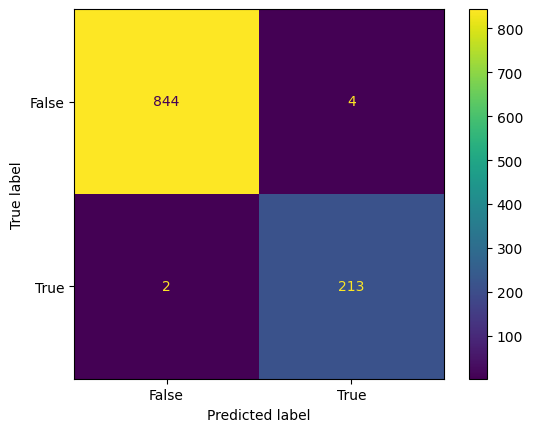

In [125]:
rf = RandomForestClassifier(random_state=42, min_samples_split=3, max_depth=None, n_estimators=30, criterion="gini")
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

In [126]:
with open("models/RandomForest3.pkl", "wb") as file:
    pkl.dump(rf, file)

In [113]:
with open("models/RandomForest3.pkl", "wb") as file:
    pkl.dump(rf, file)